In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

D:\Anaconda\envs\AI\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
train_data = tf.keras.preprocessing.image_dataset_from_directory(
    'Fruit/train',
    labels='inferred',
    label_mode='categorical',
    image_size=(128, 128),
    batch_size=8,
    shuffle=True
)

Found 5600 files belonging to 8 classes.


In [4]:
validate_data = tf.keras.preprocessing.image_dataset_from_directory(
    'Fruit/val',
    labels='inferred',
    label_mode='categorical',
    image_size=(128, 128),
    batch_size=8,
    shuffle=True
)

Found 1600 files belonging to 8 classes.


In [6]:
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(2),

    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(2),

    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(2),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(8, activation='softmax')
])

In [7]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
train_history = model.fit(
    train_data,
    validation_data=validate_data,
    epochs=50,
)

Epoch 1/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 34s 46ms/step - accuracy: 0.3088 - loss: 1.7966 - val_accuracy: 0.5169 - val_loss: 1.3919
Epoch 2/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 32s 45ms/step - accuracy: 0.5168 - loss: 1.3933 - val_accuracy: 0.6300 - val_loss: 1.1079
Epoch 3/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 34s 48ms/step - accuracy: 0.5904 - loss: 1.2205 - val_accuracy: 0.6687 - val_loss: 0.9886
Epoch 4/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 46s 66ms/step - accuracy: 0.6187 - loss: 1.1004 - val_accuracy: 0.6956 - val_loss: 0.9076
Epoch 5/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 42s 61ms/step - accuracy: 0.6546 - loss: 1.0236 - val_accuracy: 0.6956 - val_loss: 0.9038
Epoch 6/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 39s 56ms/step - accuracy: 0.6727 - loss: 0.9716 - val_accuracy: 0.7319 - val_loss: 0.8258
Epoch 7/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 39s 53ms/step - accuracy: 0.6948 - loss: 0.8849 - val_accuracy: 0.7269 - val_loss: 0.8126
Epoch 8/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.7141 - loss: 0.8346 - 

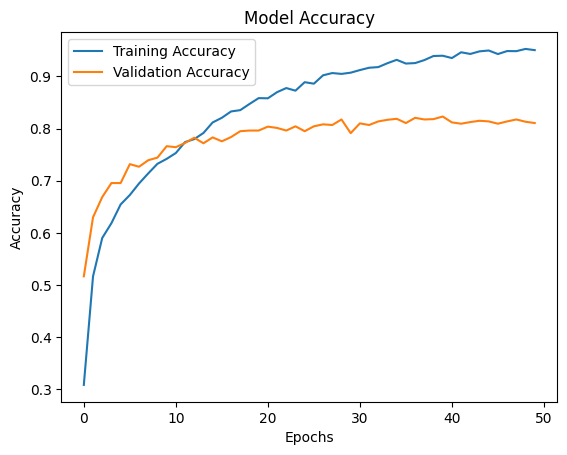

In [12]:
plt.plot(train_history.history['accuracy'], label='Training Accuracy')
plt.plot(train_history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.show()

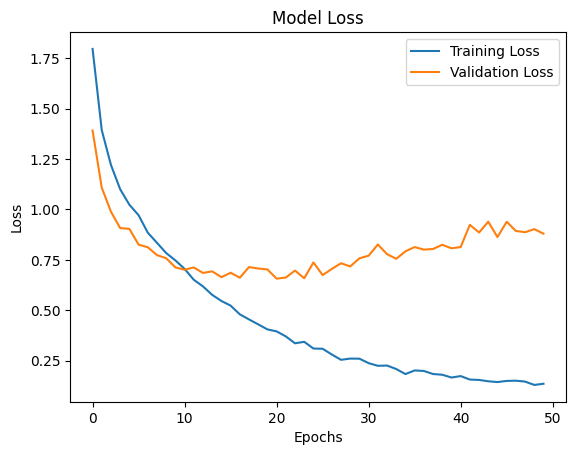

In [14]:
plt.plot(train_history.history['loss'], label='Training Loss')
plt.plot(train_history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.show()

In [16]:
test_data = tf.keras.preprocessing.image_dataset_from_directory(
    'fruit/test/',
    labels='inferred',
    label_mode='categorical',
    image_size=(128, 128),
    batch_size=8,
    shuffle=True
)
val_loss, val_acc = model.evaluate(test_data)
val_acc = val_acc *100
print(f"Test Accuracy: {val_acc:.2f}")

Found 800 files belonging to 8 classes.
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8050 - loss: 0.8046
Test Accuracy: 80.50
